# Task 1 — Preprocess & Explore (EDA)

Fetch TSLA, BND, SPY (2015-01-01 → 2026-06-30), clean, run ADF tests, compute risk metrics, and save cleaned data to `data/processed/`.

In [20]:
import sys
import os
import pathlib
# ensure project root (the folder that contains `src`) is on sys.path for `src` imports when running headless
cwd = pathlib.Path('.').resolve()
if (cwd / 'src').exists():
    sys.path.insert(0, str(cwd))
else:
    p = cwd
    while p.parent != p:
        p = p.parent
        if (p / 'src').exists():
            sys.path.insert(0, str(p))
            break

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.eda import stationarity_test, calculate_var, calculate_sharpe_ratio, compute_daily_returns

import importlib
import src.data_loader

importlib.reload(src.data_loader)

from src.data_loader import load_or_fetch_assets, clean_data, save_processed_data
# Parameters
TICKERS = ["TSLA", "BND", "SPY"]
START = "2015-01-01"
END = "2026-06-30"

In [2]:
# Load from data/processed if available, otherwise fetch and save per-ticker CSVs
df = load_or_fetch_assets(TICKERS, START, END, per_ticker=True, force_fetch=False)
df.head()

,Date,Close,High,Low,Open,Volume,Ticker,Daily Return
Date,,,,,,,,
2015-01-02,2015-01-02,59.405396,59.434147,59.240079,59.247268,2218800,BND,NaN
2015-01-05,2015-01-05,59.577888,59.599450,59.441323,59.470074,5820100,BND,0.002904
2015-01-06,2015-01-06,59.750404,59.930094,59.678530,59.678530,3887600,BND,0.002896
2015-01-07,2015-01-07,59.786343,59.858217,59.692906,59.757592,2433400,BND,0.000601
2015-01-08,2015-01-08,59.692913,59.736037,59.635411,59.736037,1873400,BND,-0.001563


In [3]:
# Quick checks: dtypes and missing values
print(df.dtypes)
print('Missing values per column:')
print(df.isna().sum())

Date            datetime64[us]
Close                  float64
High                   float64
Low                    float64
Open                   float64
Volume                   int64
Ticker                     str
Daily Return           float64
dtype: object
Missing values per column:
Date            0
Close           0
High            0
Low             0
Open            0
Volume          0
Ticker          0
Daily Return    3
dtype: int64


In [6]:
# Clean numeric gaps (forward/backfill + interpolation)
df_clean = clean_data(df, interpolate=True)
print('Missing after clean:')
print(df_clean.isna().sum())

Missing after clean:
Date            0
Close           0
High            0
Low             0
Open            0
Volume          0
Ticker          0
Daily Return    0
dtype: int64


In [7]:
# Ensure Date is a column and basic stats
if 'Date' in df_clean.index.names:
    if 'Date' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Date'])
    df_clean = df_clean.reset_index()

if 'Date' not in df_clean.columns:
    raise RuntimeError('Date column missing after reset')

# normalize dtype and re-index
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean = df_clean.sort_values(['Ticker', 'Date']).reset_index(drop=True).set_index('Date', drop=False)
print(df_clean.index.dtype)
print('Columns:', df_clean.columns.tolist())
# Find an adjusted close-like column
price_col = None
for c in df_clean.columns:
    if c.lower().replace('_','') in ('adjclose','adj_close','adjustedclose','adjusted_close') or c=='Adj Close' or c.lower()=='close':
        price_col = c
        break
if price_col is None:
    raise KeyError('No price column found (Adj Close / Close)')
print('Using price column:', price_col)
print(df_clean.groupby('Ticker')[price_col].describe())

datetime64[us]
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Daily Return']
Using price column: Close
         count        mean         std         min         25%         50%  \
Ticker                                                                       
BND     2888.0   66.503053    4.713607   58.729202   62.478085   65.728416   
SPY     2888.0  351.505532  155.443934  154.161621  223.546825  312.817902   
TSLA    2888.0  148.773923  138.895957    9.578000   18.393499  133.437668   

               75%         max  
Ticker                          
BND      70.689138   74.832878  
SPY     432.806824  757.618225  
TSLA    251.925831  489.880005  


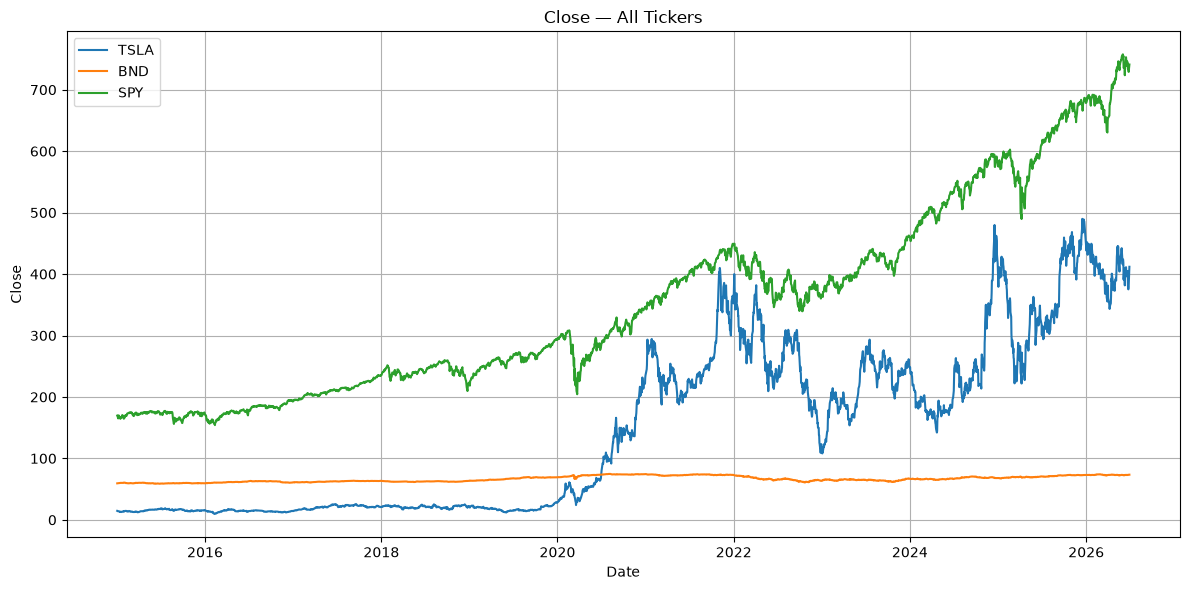

In [8]:
# Plot closing price over time for all tickers
plt.figure(figsize=(12, 6))
for t in TICKERS:
    sub = df_clean[df_clean['Ticker'] == t]
    plt.plot(sub['Date'], sub[price_col], label=t)
plt.title(f"{price_col} — All Tickers")
plt.legend()
plt.xlabel('Date')
plt.ylabel(price_col)
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# Calculate daily returns and add column
# Ensure price column is numeric
df_clean[price_col] = pd.to_numeric(df_clean[price_col], errors='coerce')
# fill small gaps if any
df_clean[price_col] = df_clean.groupby('Ticker')[price_col].transform(lambda s: s.ffill().bfill())

df_clean['Daily Return'] = df_clean.groupby('Ticker')[price_col].pct_change()
# show sample
for t in TICKERS:
    print(t, df_clean[df_clean['Ticker']==t][[price_col,'Daily Return']].head(3))

TSLA                 Close  Daily Return
Date                               
2015-01-02  14.620667           NaN
2015-01-05  14.006000     -0.042041
2015-01-06  14.085333      0.005664
BND                 Close  Daily Return
Date                               
2015-01-02  59.405396           NaN
2015-01-05  59.577888      0.002904
2015-01-06  59.750404      0.002896
SPY                  Close  Daily Return
Date                                
2015-01-02  169.687866           NaN
2015-01-05  166.623291     -0.018060
2015-01-06  165.053955     -0.009418


In [10]:
# Rolling metrics (30-day) — add columns and display sample
df_metrics = df_clean.copy()
window = 30
for t in TICKERS:
    mask = df_metrics['Ticker'] == t
    df_metrics.loc[mask, f'RollingMean_{window}'] = df_metrics.loc[mask, price_col].rolling(window, min_periods=1).mean().values
    df_metrics.loc[mask, f'RollingStd_{window}'] = df_metrics.loc[mask, 'Daily Return'].rolling(window, min_periods=1).std().values

df_metrics.groupby('Ticker')[[f'RollingMean_{window}', f'RollingStd_{window}']].tail(2)

,RollingMean_30,RollingStd_30
Date,,
2026-06-26,72.898558,0.002777
2026-06-29,72.916831,0.002776
2026-06-26,742.367826,0.009569
2026-06-29,742.192910,0.009949
2026-06-26,409.595664,0.028421
2026-06-29,408.546998,0.032787


In [11]:
# Outlier detection in returns using z-score
from scipy import stats
outliers = {}
for t in TICKERS:
    series = df_clean[df_clean['Ticker'] == t]['Daily Return'].dropna()
    if len(series) == 0:
        outliers[t] = 0
        continue
    z = np.abs(stats.zscore(series))
    thresh = 4.0
    out_idx = series.index[z > thresh].tolist()
    outliers[t] = len(out_idx)
print('Outlier counts (z>4):', outliers)

Outlier counts (z>4): {'TSLA': 17, 'BND': 11, 'SPY': 19}


In [12]:
# ADF tests on Close price and Daily returns — report p-values
results = {}
for t in TICKERS:
    sub = df_clean[df_clean['Ticker'] == t]
    close_adf = stationarity_test(sub[price_col])
    returns_adf = stationarity_test(sub['Daily Return'])
    results[t] = {'close': close_adf, 'returns': returns_adf}
    print(f'--- {t} ---')
    print('Close ADF p-value:', close_adf.get('p-value'))
    print('Returns ADF p-value:', returns_adf.get('p-value'))

--- TSLA ---
Close ADF p-value: 0.7270419411549215
Returns ADF p-value: 0.0
--- BND ---
Close ADF p-value: 0.7219191155282174
Returns ADF p-value: 5.568129221204152e-28
--- SPY ---
Close ADF p-value: 0.9966585458225286
Returns ADF p-value: 4.046310689494035e-30


In [13]:
# Risk metrics — VaR (5%) & Sharpe for each asset
metrics = {}
for t in TICKERS:
    series = df_clean[df_clean['Ticker'] == t]['Daily Return'].dropna()
    if len(series) == 0:
        metrics[t] = {'VaR_5pct': None, 'Sharpe': None}
        continue
    var = calculate_var(series, confidence_level=0.05)
    sharpe = calculate_sharpe_ratio(series, risk_free_rate=0.0)
    metrics[t] = {'VaR_5pct': var, 'Sharpe': sharpe}
pd.DataFrame(metrics).T

,VaR_5pct,Sharpe
TSLA,-0.051664,0.050053
BND,-0.004756,0.023664
SPY,-0.016650,0.051504


In [21]:
# Save cleaned combined dataset to data/processed/all_assets.csv and per-ticker files
save_processed_data(df_clean, 'all_assets.csv')
for t in TICKERS:
    sub = df_clean[df_clean['Ticker'] == t].reset_index(drop=True)
    save_processed_data(sub, f'{t}.csv')
print('Saved cleaned data to ../data/processed/')

hi
hi
hi
hi
Saved cleaned data to ../data/processed/


## Write up (to fill):
- Data quality issues and handling steps
- Stationarity results and implied `d` for each series
- Key insights from plots and risk metrics